<a href="https://colab.research.google.com/github/azelepou/IntroMachineLearning/blob/main/ML_HW2_AnatolyZelepouga_801236217.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rows: 545
Training rows: 436
Evaluation rows: 109
1a raw: method=raw, alpha=0.03, lambda=0.00, iterations=9910, training loss=0.773544, evaluation loss=0.750915
1a normalization: method=normalization, alpha=0.05, lambda=0.00, iterations=19096, training loss=0.773544, evaluation loss=0.750915
1a standardization: method=standardization, alpha=0.01, lambda=0.00, iterations=2554, training loss=0.773544, evaluation loss=0.750915
1a best scaled method: standardization
1b raw: method=raw, alpha=0.03, lambda=0.00, iterations=13209, training loss=0.579433, evaluation loss=0.565923
1b normalization: method=normalization, alpha=0.05, lambda=0.00, iterations=21439, training loss=0.579433, evaluation loss=0.565923
1b standardization: method=standardization, alpha=0.10, lambda=0.00, iterations=373, training loss=0.579433, evaluation loss=0.565923
1b best scaled method: standardization
3a regularized: method=standardization, alpha=0.01, lambda=1.00, iterations=2544, training loss=0.774945, evaluation

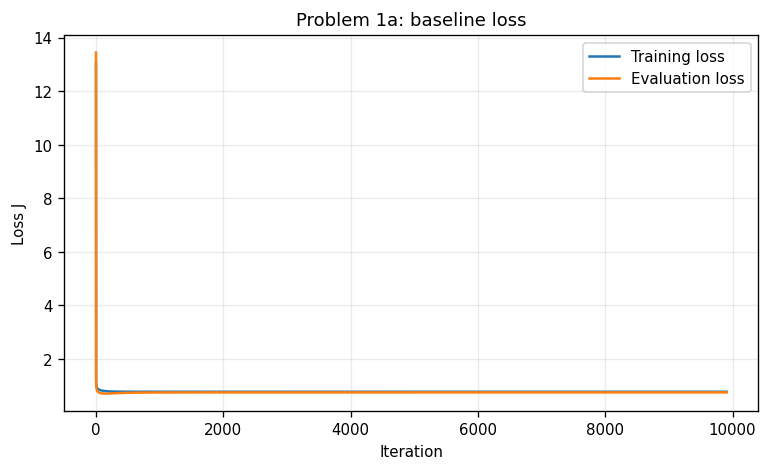

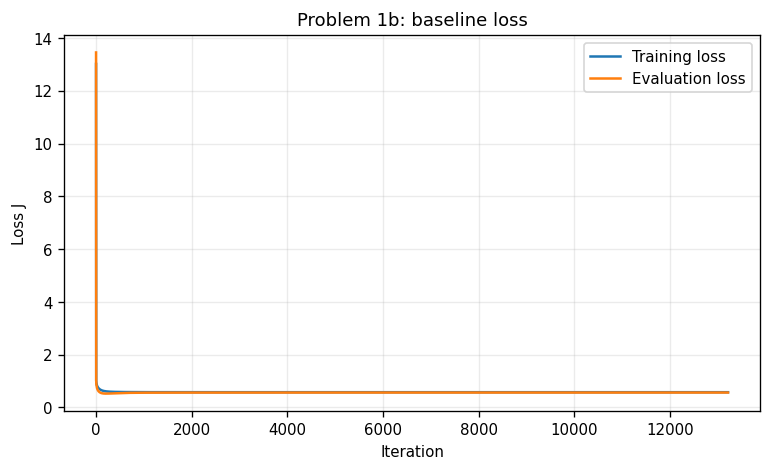

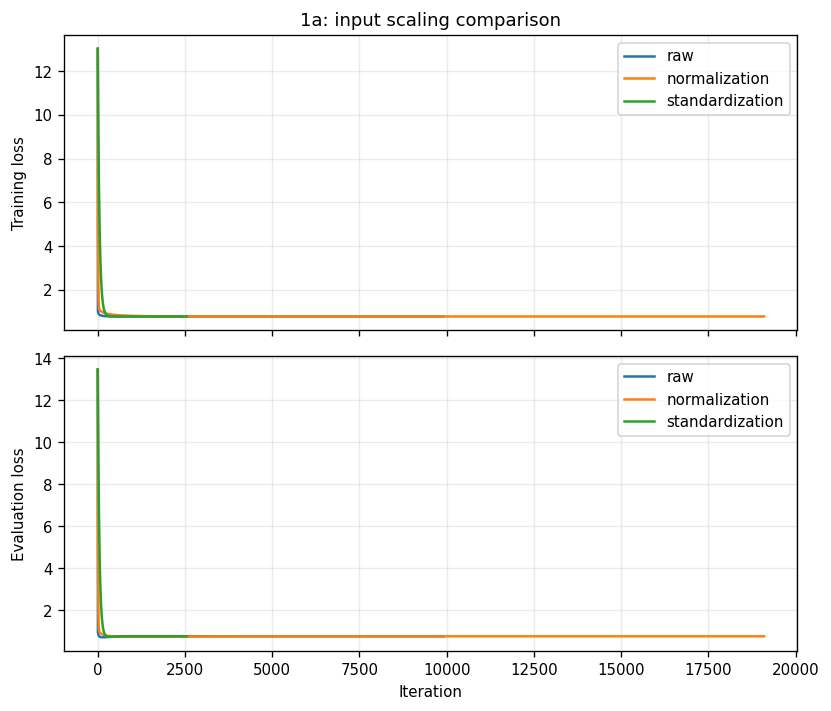

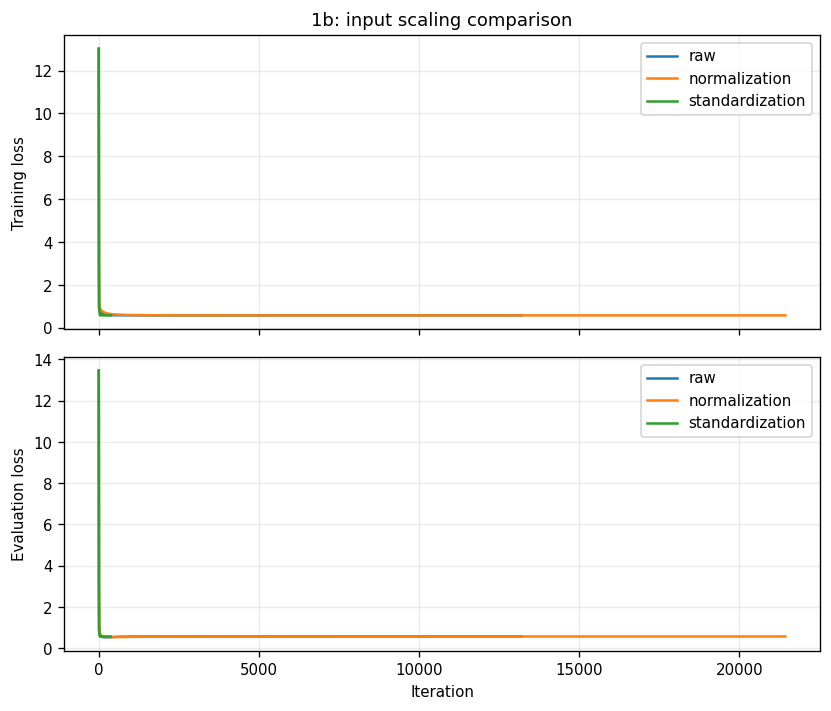

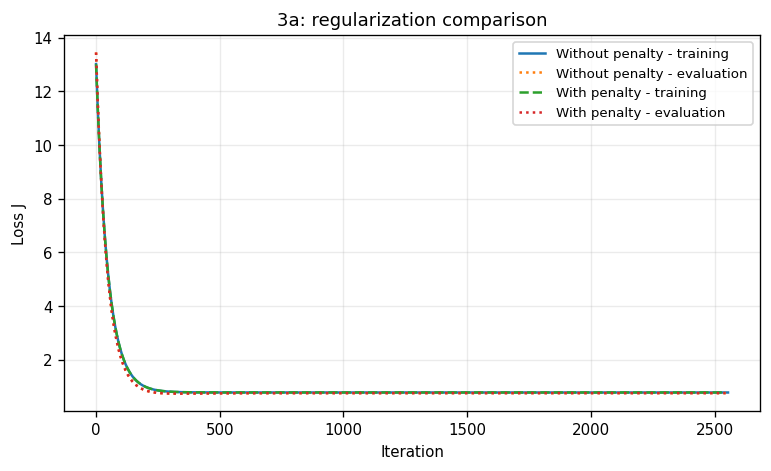

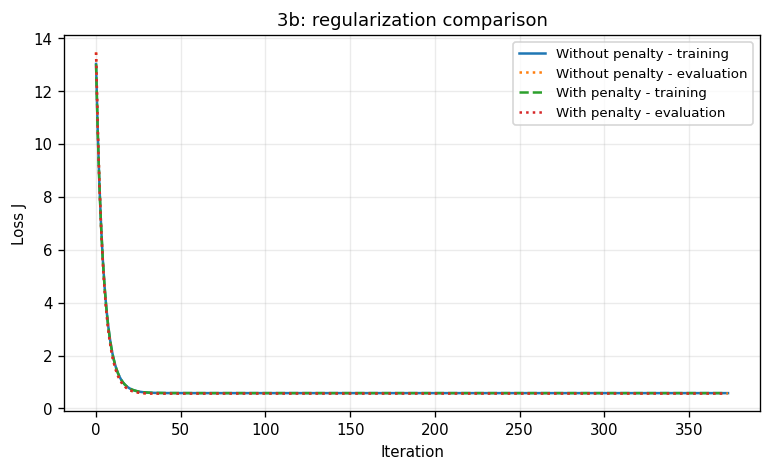

Results saved in hw2_results/


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Load data
DATA_FILE = Path("Housing.csv")

if not DATA_FILE.exists():
    from google.colab import files
    files.upload()

RESULTS_DIR = Path("hw2_results")
RESULTS_DIR.mkdir(exist_ok=True)

data = pd.read_csv(DATA_FILE)

features_1a = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking",
]

features_1b = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "parking",
    "prefarea",
]

binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
]

for column in binary_columns:
    data[column] = data[column].map({
        "no": 0.0,
        "yes": 1.0
    })


def make_features(columns):
    X = data[columns].to_numpy(dtype=float)
    X[:, 0] = X[:, 0] / 1000.0
    return X


# Use millions of dollars for numerical stability.
y = data["price"].to_numpy(dtype=float) / 1_000_000.0

rng = np.random.default_rng(42)
indices = rng.permutation(len(y))

n_train = int(0.80 * len(y))

train_index = indices[:n_train]
eval_index = indices[n_train:]

learning_rates = [0.10, 0.05, 0.03, 0.01]
penalties = [0.01, 0.10, 1.00]

max_iterations = 25_000
tolerance = 1e-9

print(f"Rows: {len(data)}")
print(f"Training rows: {len(train_index)}")
print(f"Evaluation rows: {len(eval_index)}")


# Cost and scaling
def add_intercept(X):
    return np.column_stack((
        np.ones(len(X)),
        X
    ))


def fit_scaler(X, method):
    if method == "raw":
        center = np.zeros(X.shape[1])
        scale = np.ones(X.shape[1])

    elif method == "normalization":
        center = X.min(axis=0)
        scale = X.max(axis=0) - center
        scale[scale == 0] = 1.0

    else:
        center = X.mean(axis=0)
        scale = X.std(axis=0)
        scale[scale == 0] = 1.0

    return center, scale


def scale_features(X, center, scale):
    return (X - center) / scale


def cost(X, y_values, theta, penalty=0.0):
    error = X @ theta - y_values

    base_cost = (
        error @ error
        / (2 * len(y_values))
    )

    penalty_cost = (
        penalty
        * (theta[1:] @ theta[1:])
        / (2 * len(y_values))
    )

    return float(base_cost + penalty_cost)


# Gradient descent
def gradient_descent(
    X_train,
    y_train,
    X_eval,
    y_eval,
    alpha,
    penalty=0.0,
):
    theta = np.zeros(X_train.shape[1])

    train_loss = [
        cost(X_train, y_train, theta, penalty)
    ]

    eval_loss = [
        cost(X_eval, y_eval, theta)
    ]

    converged = False

    for _ in range(max_iterations):
        previous_theta = theta.copy()

        with np.errstate(
            over="ignore",
            invalid="ignore"
        ):
            error = X_train @ theta - y_train

            gradient = (
                X_train.T @ error
                / len(y_train)
            )

            gradient[1:] += (
                penalty
                * theta[1:]
                / len(y_train)
            )

            theta = theta - alpha * gradient

            current_train_loss = cost(
                X_train,
                y_train,
                theta,
                penalty,
            )

            current_eval_loss = cost(
                X_eval,
                y_eval,
                theta,
            )

        if (
            not np.isfinite(theta).all()
            or not np.isfinite(current_train_loss)
            or not np.isfinite(current_eval_loss)
        ):
            return None

        train_loss.append(current_train_loss)
        eval_loss.append(current_eval_loss)

        step = np.linalg.norm(
            theta - previous_theta
        )

        if step <= tolerance:
            converged = True
            break

    return {
        "theta": theta,
        "train_loss": np.asarray(train_loss),
        "eval_loss": np.asarray(eval_loss),
        "iterations": len(train_loss) - 1,
        "alpha": alpha,
        "penalty": penalty,
        "converged": converged,
    }


def prepare_data(X, method):
    X_train_raw = X[train_index]
    X_eval_raw = X[eval_index]

    center, scale = fit_scaler(
        X_train_raw,
        method,
    )

    X_train = add_intercept(
        scale_features(
            X_train_raw,
            center,
            scale,
        )
    )

    X_eval = add_intercept(
        scale_features(
            X_eval_raw,
            center,
            scale,
        )
    )

    return X_train, X_eval, center, scale


def run_experiments(
    X,
    method,
    penalty_values=(0.0,),
):
    X_train, X_eval, center, scale = prepare_data(
        X,
        method,
    )

    results = []

    for penalty in penalty_values:

        for alpha in learning_rates:

            result = gradient_descent(
                X_train,
                y[train_index],
                X_eval,
                y[eval_index],
                alpha,
                penalty,
            )

            if result is not None:
                result.update({
                    "method": method,
                    "center": center,
                    "scale": scale,
                })

                results.append(result)

    return results


def choose_best(results):
    converged_results = [
        result
        for result in results
        if result["converged"]
    ]

    if converged_results:
        results = converged_results

    return min(
        results,
        key=lambda result: (
            result["eval_loss"][-1],
            result["iterations"],
        ),
    )


def choose_scaling(
    normalized,
    standardized,
):
    best_loss = min(
        normalized["eval_loss"][-1],
        standardized["eval_loss"][-1],
    )

    if (
        standardized["eval_loss"][-1]
        <= best_loss + 1e-6
    ):
        return standardized

    return normalized


def original_units(
    theta,
    center,
    scale,
):
    slopes = theta[1:] / scale

    intercept = (
        theta[0]
        - np.sum(
            theta[1:]
            * center
            / scale
        )
    )

    return np.r_[
        intercept,
        slopes,
    ]


models = {
    "1a": (
        features_1a,
        make_features(features_1a),
    ),
    "1b": (
        features_1b,
        make_features(features_1b),
    ),
}

all_results = {}
best = {}


# Problems 1 and 2
for label, (_, X) in models.items():

    for method in [
        "raw",
        "normalization",
        "standardization",
    ]:
        all_results[
            (label, method)
        ] = run_experiments(
            X,
            method,
        )

        best[
            (label, method)
        ] = choose_best(
            all_results[
                (label, method)
            ]
        )

    best[
        (label, "scaled")
    ] = choose_scaling(
        best[
            (label, "normalization")
        ],
        best[
            (label, "standardization")
        ],
    )


# Problems 3a and 3b
for label, source_label in [
    ("3a", "1a"),
    ("3b", "1b"),
]:
    columns, X = models[source_label]

    method = best[
        (source_label, "scaled")
    ]["method"]

    all_results[
        (label, "regularized")
    ] = run_experiments(
        X,
        method,
        penalties,
    )

    best[
        (label, "regularized")
    ] = choose_best(
        all_results[
            (label, "regularized")
        ]
    )


# Print selected results
def print_result(name, result):
    print(
        f"{name}: "
        f"method={result['method']}, "
        f"alpha={result['alpha']:.2f}, "
        f"lambda={result['penalty']:.2f}, "
        f"iterations={result['iterations']}, "
        f"training loss={result['train_loss'][-1]:.6f}, "
        f"evaluation loss={result['eval_loss'][-1]:.6f}"
    )


for label in ["1a", "1b"]:

    print_result(
        f"{label} raw",
        best[(label, "raw")],
    )

    print_result(
        f"{label} normalization",
        best[(label, "normalization")],
    )

    print_result(
        f"{label} standardization",
        best[(label, "standardization")],
    )

    print(
        f"{label} best scaled method: "
        f"{best[(label, 'scaled')]['method']}"
    )


print_result(
    "3a regularized",
    best[("3a", "regularized")],
)

print_result(
    "3b regularized",
    best[("3b", "regularized")],
)


# Coefficients in original units
coefficient_rows = []

for label in ["1a", "1b"]:

    columns, _ = models[label]

    for method in [
        "raw",
        "normalization",
        "standardization",
    ]:

        result = best[
            (label, method)
        ]

        theta = original_units(
            result["theta"],
            result["center"],
            result["scale"],
        )

        row = {
            "experiment": label,
            "method": method,
            "alpha": result["alpha"],
            "lambda": result["penalty"],
            "intercept_millions": theta[0],
        }

        row.update({
            f"coefficient_{column}": value
            for column, value in zip(
                columns,
                theta[1:],
            )
        })

        coefficient_rows.append(row)


for label, source_label in [
    ("3a", "1a"),
    ("3b", "1b"),
]:

    columns, _ = models[source_label]

    result = best[
        (label, "regularized")
    ]

    theta = original_units(
        result["theta"],
        result["center"],
        result["scale"],
    )

    row = {
        "experiment": label,
        "method": result["method"],
        "alpha": result["alpha"],
        "lambda": result["penalty"],
        "intercept_millions": theta[0],
    }

    row.update({
        f"coefficient_{column}": value
        for column, value in zip(
            columns,
            theta[1:],
        )
    })

    coefficient_rows.append(row)


pd.DataFrame(
    coefficient_rows
).to_csv(
    RESULTS_DIR / "selected_coefficients.csv",
    index=False,
)


for label, key in [
    ("1a", ("1a", "raw")),
    ("1b", ("1b", "raw")),
    ("3a", ("3a", "regularized")),
    ("3b", ("3b", "regularized")),
]:

    result = best[key]

    theta = original_units(
        result["theta"],
        result["center"],
        result["scale"],
    )

    print(
        f"{label} coefficients:",
        np.round(theta, 6),
    )


# Plots
def plot_loss(
    result,
    title,
    filename,
):
    iterations = np.arange(
        len(result["train_loss"])
    )

    plt.figure(figsize=(6.5, 4))

    plt.plot(
        iterations,
        result["train_loss"],
        label="Training loss",
    )

    plt.plot(
        iterations,
        result["eval_loss"],
        label="Evaluation loss",
    )

    plt.xlabel("Iteration")
    plt.ylabel("Loss J")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR / filename,
        dpi=220,
    )

    plt.show()
    plt.close()


def plot_scaling(
    label,
    filename,
):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(7, 6),
        sharex=True,
    )

    for method in [
        "raw",
        "normalization",
        "standardization",
    ]:

        result = best[
            (label, method)
        ]

        iterations = np.arange(
            len(result["train_loss"])
        )

        axes[0].plot(
            iterations,
            result["train_loss"],
            label=method,
        )

        axes[1].plot(
            iterations,
            result["eval_loss"],
            label=method,
        )

    axes[0].set_ylabel("Training loss")
    axes[1].set_ylabel("Evaluation loss")
    axes[1].set_xlabel("Iteration")
    axes[0].set_title(
        f"{label}: input scaling comparison"
    )

    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend()

    fig.tight_layout()

    fig.savefig(
        RESULTS_DIR / filename,
        dpi=220,
    )

    plt.show()
    plt.close(fig)


def plot_regularization(
    label,
    source_label,
    filename,
):
    regularized = best[
        (label, "regularized")
    ]

    unregularized = best[
        (source_label, "scaled")
    ]

    plt.figure(figsize=(6.5, 4))

    for result, name, style in [
        (
            unregularized,
            "Without penalty",
            "-",
        ),
        (
            regularized,
            "With penalty",
            "--",
        ),
    ]:

        iterations = np.arange(
            len(result["train_loss"])
        )

        plt.plot(
            iterations,
            result["train_loss"],
            linestyle=style,
            label=f"{name} - training",
        )

        plt.plot(
            iterations,
            result["eval_loss"],
            linestyle=":",
            label=f"{name} - evaluation",
        )

    plt.xlabel("Iteration")
    plt.ylabel("Loss J")
    plt.title(
        f"{label}: regularization comparison"
    )
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR / filename,
        dpi=220,
    )

    plt.show()
    plt.close()


plot_loss(
    best[("1a", "raw")],
    "Problem 1a: baseline loss",
    "problem_1a_loss.png",
)

plot_loss(
    best[("1b", "raw")],
    "Problem 1b: baseline loss",
    "problem_1b_loss.png",
)

plot_scaling(
    "1a",
    "problem_2a_scaling.png",
)

plot_scaling(
    "1b",
    "problem_2b_scaling.png",
)

plot_regularization(
    "3a",
    "1a",
    "problem_3a_regularization.png",
)

plot_regularization(
    "3b",
    "1b",
    "problem_3b_regularization.png",
)


# Save a summary table
summary_rows = []

for (label, method), results in all_results.items():

    for result in results:

        summary_rows.append({
            "experiment": label,
            "method": method,
            "alpha": result["alpha"],
            "lambda": result["penalty"],
            "iterations": result["iterations"],
            "training_loss": result["train_loss"][-1],
            "evaluation_loss": result["eval_loss"][-1],
        })


pd.DataFrame(
    summary_rows
).to_csv(
    RESULTS_DIR / "experiment_summary.csv",
    index=False,
)

print(
    f"Results saved in {RESULTS_DIR}/"
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive
